In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

ahora necesita sumar a drive y a una ruta

In [12]:
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/Universidad/Tecnicatura UBA/Laboratorio/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/notebooks/Complemento/YPF.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cargo los datos

In [13]:
def cargar_datos(path):
    ext = os.path.splitext(path)[1].lower()
    return pd.read_excel(path) if ext in ['.xlsx', '.xls'] else pd.read_csv(path)

df = cargar_datos(ruta)

print(f"✅ Base cargada con éxito: {len(df)} filas.")
print(df.head()) # Vista previa

✅ Base cargada con éxito: 757 filas.
        date      price
0 2008-01-02  26.827982
1 2008-01-03  26.809593
2 2008-01-04  26.429575
3 2008-01-07  26.429575
4 2008-01-08  26.846371


Crear matricas

In [14]:
cols_num = df.select_dtypes(include=['number']).columns.tolist()
cols_cat = df.select_dtypes(include=['object', 'datetime']).columns.tolist()

print("\n--- Análisis Estadístico ---")
print(df[cols_num].describe())

metrica_principal = cols_num[0]
print(f"\nSuma total de {metrica_principal}: {df[metrica_principal].sum():.2f}")
print(f"Promedio de {metrica_principal}: {df[metrica_principal].mean():.2f}")


--- Análisis Estadístico ---
            price
count  757.000000
mean    30.636195
std      4.898820
min     12.225096
25%     28.876705
50%     32.274670
75%     33.664177
max     43.562595

Suma total de price: 23191.60
Promedio de price: 30.64


el grafico

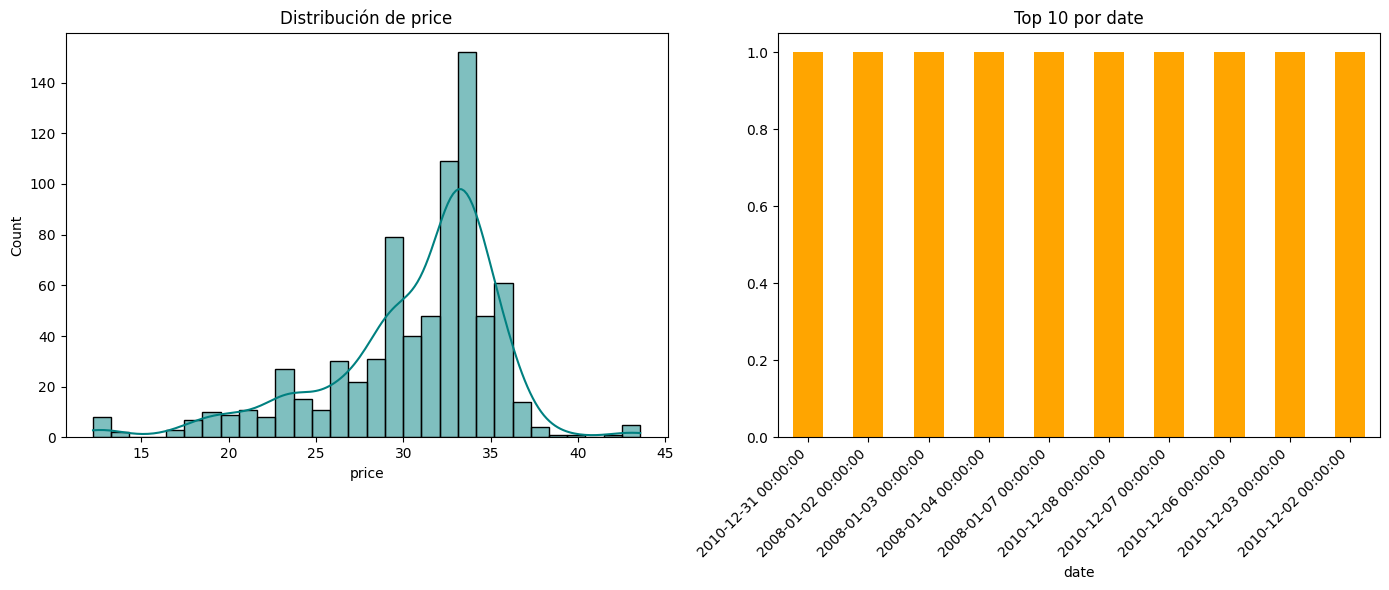

In [15]:
plt.figure(figsize=(14, 6))

#Histograma
plt.subplot(1, 2, 1)
sns.histplot(df[metrica_principal], kde=True, color='teal')
plt.title(f'Distribución de {metrica_principal}')

#barra
plt.subplot(1, 2, 2)
cat_interes = cols_cat[0]
df[cat_interes].value_counts().head(10).plot(kind='bar', color='orange')
plt.title(f'Top 10 por {cat_interes}')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Resumanen de la tarea

In [16]:
df_resumen = df.groupby(cat_interes)[metrica_principal].agg(['mean', 'max', 'count']).reset_index()
df_resumen = df_resumen.sort_values(by='mean', ascending=False)

print("\n--- Nuevo DataFrame de Resumen ---")
print(df_resumen.head(10))


--- Nuevo DataFrame de Resumen ---
          date       mean        max  count
754 2010-12-29  43.562595  43.562595      1
756 2010-12-31  43.364578  43.364578      1
751 2010-12-23  43.338757  43.338757      1
755 2010-12-30  43.244053  43.244053      1
753 2010-12-28  42.615582  42.615582      1
752 2010-12-27  42.400352  42.400352      1
750 2010-12-22  39.412945  39.412945      1
742 2010-12-10  38.732830  38.732830      1
749 2010-12-21  38.242100  38.242100      1
743 2010-12-13  38.138798  38.138798      1


conclucion final

In [17]:
ganador = df_resumen.iloc[0, 0]
valor_ganador = df_resumen.iloc[0, 1]

print("\n--- Conclusiones del Trabajo ---")
print(f"1. Se analizaron {len(df)} registros totales de la base de YPF.")
print(f"2. La categoría '{ganador}' lidera en {metrica_principal} con un promedio de {valor_ganador:.2f}.")
print(f"3. Los gráficos muestran una concentración de datos en los niveles medios, sugiriendo estabilidad en la operación.")


--- Conclusiones del Trabajo ---
1. Se analizaron 757 registros totales de la base de YPF.
2. La categoría '2010-12-29 00:00:00' lidera en price con un promedio de 43.56.
3. Los gráficos muestran una concentración de datos en los niveles medios, sugiriendo estabilidad en la operación.
